In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from get_ddf import get_hourly_df
from data_handling import *
import statsmodels.api as sm
from scipy.stats import gaussian_kde as kde
import sys 
from scipy.optimize import minimize
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *

import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']
coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemon_creek':'58.5_-134.3',
                'gulkana':'63.5_-145.6'}
site_dict = {
    'kahiltna':['K17b','K53'], # KAHILTNA     'KPS','K14k',
    'kennicott':['GTH','KC31','GTL'], # KENNICOTT
    'gulkana':['AU','B','D'], # GULKANA
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['MG1','NWB1','TKG3'], # TAKU
}

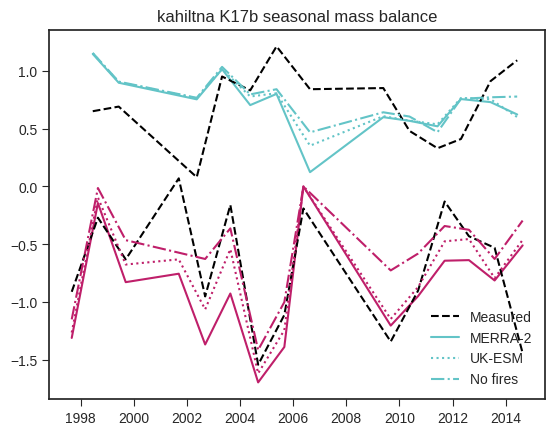

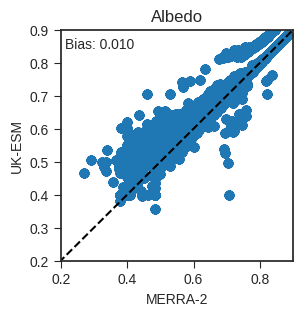

In [6]:
glacier, site = 'kahiltna', 'K17b'

ds_merra2 = xr.open_dataset(base_fp + glacier+site+'_2026_04_06_merra2_0.nc')
ds_ukesm = xr.open_dataset(base_fp + glacier+site+'_2026_04_06_gfed_0.nc')
ds_nofires = xr.open_dataset(base_fp + glacier+site+'_2026_04_06_nofires_0.nc')

mb = MassBalance(glacier, site)
mb.get_model_mb(ds_merra2)
mod_merra2, meas = (mb.mod, mb.meas)
fig, ax = mb.plot_mb(mod_label='MERRA-2')

mb.get_model_mb(ds_ukesm)
mod_ukesm, meas = (mb.mod, mb.meas)
ends = mb.period_ends
if 'seasonal' in mb.dataset:
    idx_summer = mb.idx_summer 
    idx_winter = mb.idx_winter
    ax.plot(ends[idx_summer], mod_ukesm[idx_summer], color=colors[4], linestyle=':')
    ax.plot(ends[idx_winter], mod_ukesm[idx_winter], color=colors[0], linestyle=':', label='UK-ESM')
else:
    ax.plot(ends, mod_ukesm, color=colors[0], linestyle=':', label='UK-ESM')

mb.get_model_mb(ds_nofires)
mod_nofires, meas = (mb.mod, mb.meas)
if 'seasonal' in mb.dataset:
    idx_summer = mb.idx_summer 
    idx_winter = mb.idx_winter
    ax.plot(ends[idx_summer], mod_nofires[idx_summer], color=colors[4], linestyle='-.')
    ax.plot(ends[idx_winter], mod_nofires[idx_winter], color=colors[0], linestyle='-.', label='No fires')
else:
    ax.plot(ends, mod_nofires, color=colors[0], linestyle='-.', label='No fires')

ax.legend()
ax.tick_params(length=5)
plt.show()

albedo_merra2 = ds_merra2.albedo.values # .layerBC.isel(layer=0).values # 
albedo_ukesm = ds_ukesm.albedo.values
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(albedo_merra2, albedo_ukesm)
bias = np.nanmean(albedo_ukesm - albedo_merra2)
ax.text(0.02, 0.92, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.plot([0,1],[0,1],'k--',label='1:1')
ax.set_xlim(0.2,0.9)
ax.set_ylim(0.2,0.9)
ax.set_ylabel('UK-ESM')
ax.set_xlabel('MERRA-2')
ax.set_title('Albedo')
ax.tick_params(length=5)
plt.show()

In [ ]:
site_dict = {
    'kahiltna':['K17b','K53','K14k'], # KAHILTNA     'KPS',
    'kennicott':['KC31','GTL','GTH',], # KENNICOTT 
    'gulkana':['AU','B','D'], # GULKANA  
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C', 'D'], # LEMON CREEK
    'taku':['NWB1','MG1','TKG3'], # TAKU    
}

all_albedo = {'mod':[], 'meas':[], 'time':[]}
for glacier in ['gulkana']: # site_dict:
    for site in site_dict[glacier]:
        albedo = Albedo(glacier, site, use='all')
        ds = xr.open_dataset(base_fp + glacier + site +'_2026_03_19_long_0.nc')
        albedo.get_model_albedo(ds, months_range=list(range(4, 9)))
        # albedo.plot_timeseries()

        for mod, meas, date in zip(albedo.mod, albedo.meas, albedo.time):
            all_albedo['mod'].append(mod)
            all_albedo['meas'].append(meas)
            all_albedo['time'].append(date)

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)
markers = {'wolverine':'*', 'gulkana':'o', 'kahiltna':'3', 'kennicott':'^','lemon_creek':'.','taku':'1'}
# for glacier in site_dict:
#     for site in site_dict[glacier]:
#         albedo = Albedo(glacier, site)
#         ds = xr.open_dataset(base_fp + glacier + site +'_2026_03_04_base_3.nc')
#         albedo.get_model_albedo(ds)
#         ax.scatter(albedo.meas, albedo.mod, alpha=0.6, label=glacier, c=cmap(norm(pd.to_datetime(albedo.time).month)), marker=markers[glacier])
ax.scatter(all_albedo['meas'], all_albedo['mod'], alpha=0.6, label='Data', c=cmap(norm(pd.to_datetime(all_albedo['time']).month)))
ax.plot([0,1],[0,1],'k--',label='1:1')

bias = np.nanmean(np.array(all_albedo['mod']) - np.array(all_albedo['meas']))
mae = np.nanmean(np.abs(np.array(all_albedo['meas']) - np.array(all_albedo['mod'])))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.tick_params(length=5)
ax.set_ylabel('Modeled albedo')
ax.set_xlabel('Measured albedo')
plt.show()

In [6]:
measurements = {'B':('2024-06-19', 5.102),
                'D':('2024-08-21', 10.51)}

for site in measurements:
    ds = xr.open_dataset(base_fp + f'gulkana{site}_2026_03_19_long_0.nc')
    
    # dsc = ds.sel(time=slice(pd.to_datetime(measurements[site][0]) - pd.Timedelta(days=1), pd.to_datetime(measurements[site][0]) + pd.Timedelta(days=1)))
    # plt.plot(dsc.time, dsc.layerBC.isel(layer=range(3)).mean(dim='layer'))
    # plt.show()
    date = measurements[site][0]
    modeled = ds.sel(time=pd.to_datetime(date)).layerBC.isel(layer=range(3)).mean()
    print(f'Gulkana {site} on {date}')
    print('   Measured:', measurements[site][1],'ppb')
    print(f'   Modeled: {modeled:.2f} ppb')

Gulkana B on 2024-06-19
   Measured: 5.102 ppb
   Modeled: 36.36 ppb
Gulkana D on 2024-08-21
   Measured: 10.51 ppb
   Modeled: 28.32 ppb
